In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

from math import exp, sqrt, pi, log

Code to sample from a weird function using Metropolis Algorithm

In [2]:
def t(x): #this is our target distribution, but without normalizing constant. we can actually find the normalizing constant though :)
    if x>=3:
        return exp(-(x-3)) + exp(-(x-3)**5/3)
    if x<3:
        return exp(-(x-3)**2/2) + exp((x-3))

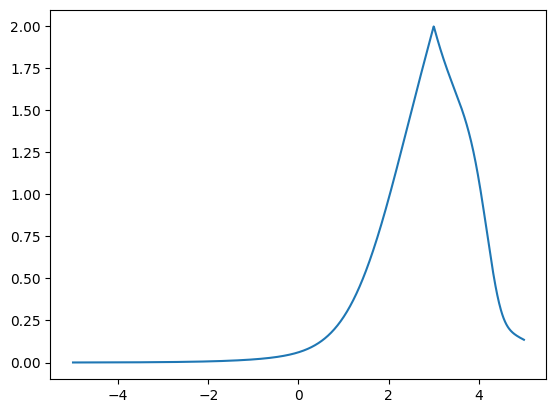

In [3]:
x_axis = np.linspace(-5, 5, num=1000)
y_axis = []
for x in x_axis:
    y_axis.append(t(x))

plt.plot(x_axis, y_axis)

In [ ]:
# i am using a symmetric normal distribution for my proposal distribution, x_t+1 ~ N(x_t, 2), variance im taking as hyperparameter

samples_with_burn_in = [2] #i am initializing at 2 because the density there isn't too high, but not so close to the tails
n = 10**8


def g(j, i): #j given i
    return (exp(-0.5*((j - i)**2)/2)/sqrt(2*pi*2))

for i in range(n):
    proposal = np.random.normal(samples_with_burn_in[-1], 2)
    current_sample = samples_with_burn_in[-1]
    
    r_g = g(proposal, current_sample)/g(current_sample, proposal)

    r_t = t(proposal)/t(samples_with_burn_in[-1])
    A = min(1, r_g*r_t)

    if np.random.random() < A:
        samples_with_burn_in.append(proposal)
    else:
        samples_with_burn_in.append(current_sample)
    

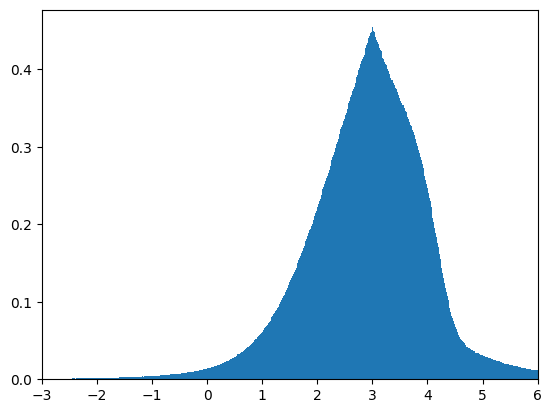

In [12]:
samples = samples_with_burn_in[100:]
plt.hist(samples, bins=2000, density=True) #this follows the distribution t(x), but its normalized!
plt.xlim(-3,6)
plt.show()

Autocorrelation between successive samples is quite high.

In [6]:
print(scipy.stats.pearsonr(samples[:-1], samples[1:])[0])

0.7175006724600086


# Monte Carlo Integration

1. Finding Integral by Sampling over Uniform
2. Importance Sampling

Calculating: $I = \int_{-10}^{10} t(x)dx$ (Because the tails are heavy, -10 to 10 will give us a good approximation)

The actual value(calculated through wolfram-alpha) is $\sim 4.397$.

### Sampling from uniform distribution
$X \sim Unif(-10, 10) \implies f_X(x) = \begin{cases} \frac{1}{20}, & \text{if } x \in [-10,10] \\ 0 & \text{otherwise} \end{cases}$

$E[t(x)] = \int_{-10}^{10} t(x)f_X(x) dx = \frac{I}{20}  \implies I = 20E[t(x)]$

This can be thought of as taking the area of multiple rectangles of height $t(x_i)$ and width $20$, then averaging them out where $x_i$ is a sample of $X$.

In [ ]:
N = 10**7
I = 0

B = 50 #bounds
np.random.seed(42)

for i in range(N):
    x = 2*B*(np.random.random() - 0.5)
    I += (2*B/N)*t(x)


print(I) #4.395836810033193 is actually really good

4.395836810033193


### Importance Sampling

Instead of sampling uniformly, we recognize that sampling near the tails is not useful because numerically it contributes nothing.

So instead we sample from some p.d.f. $g(x)$ whose density is high where the value of $t(x)$ is large.

In this situation $g(x) \sim N(0, 4/3)$ is a decent choice. The density is high near one, and about 3 standard deviations later, $t(x)$ gets pretty close to 0

$E[t(x)] = \int_{-10}^{10} t(x)g(x)dx$

But this is the incorrect integral. So we instead find the expectation of:
$E\left[\frac{t(x)}{g(x)}\right] = \int_{-\infty}^{\infty} t(x)dx = I$

Here, since the domain of $g(x)$ is the same as the domain of $t(x)$, we don't have to bound our integral either.

In [ ]:
N = 10**4
I_is = 0 #integral from importance sampling

np.random.seed(42)
mu_g = 3
std_g = 1.35

def g(x):
    return (exp( -0.5 * (((x-mu_g)/std_g)**2) )) / (sqrt(2*pi)*(std_g))

for i in range(N):
    x = np.random.normal(mu_g, std_g)
    I_is += t(x)/(N*g(x))


print(I_is) #4.3950943057939895 is pretty good.

4.3950943057939895


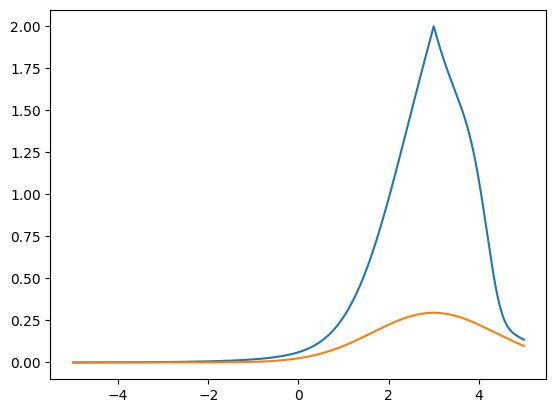

In [14]:
x_axis = np.linspace(-5, 5, num=1000)
y_axis_t = []
y_axis_g = []
for x in x_axis:
    y_axis_t.append(t(x))
    y_axis_g.append(g(x))

plt.plot(x_axis, y_axis_t)
plt.plot(x_axis, y_axis_g)

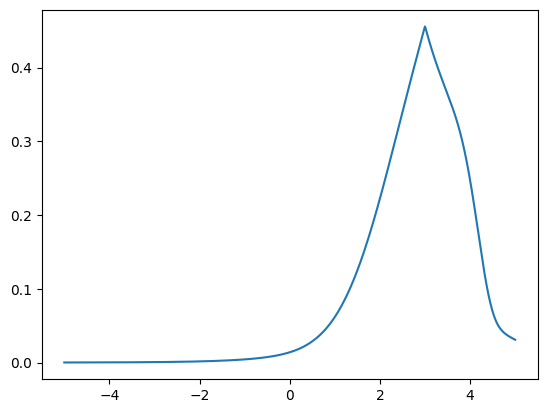

In [10]:
y_axis_normalized = []
for x in x_axis:
    y_axis_normalized.append(t(x)/I)

plt.plot(x_axis, y_axis_normalized)